G_tot = 0.000111498; gam_out = 0.00635977
G1 = 5.13909e-07; G6 = 0.955939
length = (310,)
G_interp.row(0)   4.3059e-05   4.2999e-07   4.8075e-08   8.4313e-08   6.7071e-05   2.5467e-07   4.0090e-09   5.4674e-07   7.0209e-10

G_interp.row(200)   2.7059e-05   1.2007e-06   1.3575e-07   4.4528e-07   7.9437e-05   3.3336e-07   2.2160e-08   2.8608e-06   3.8841e-09

Casting arma::mat to NumPy array with shape (310, 9) and strides (8, 2480)
Casting arma::mat to NumPy array with shape (310, 9) and strides (8, 2480)
states.keys() =  dict_keys(['G', 'BCa', 'Ca', 'Ca_in'])
G.shape = (310, 9)
state.G row 1 = [4.30590249e-05 4.29985161e-07 4.80753510e-08 8.43131147e-08
 6.70708395e-05 2.54666509e-07 4.00898658e-09 5.46744694e-07
 7.02085136e-10]
G_interp row 1 = [4.30590249e-05 4.29985161e-07 4.80753510e-08 8.43131147e-08
 6.70708395e-05 2.54666509e-07 4.00898658e-09 5.46744694e-07
 7.02085136e-10]
G row 2 sum = 0.00011149836024999999


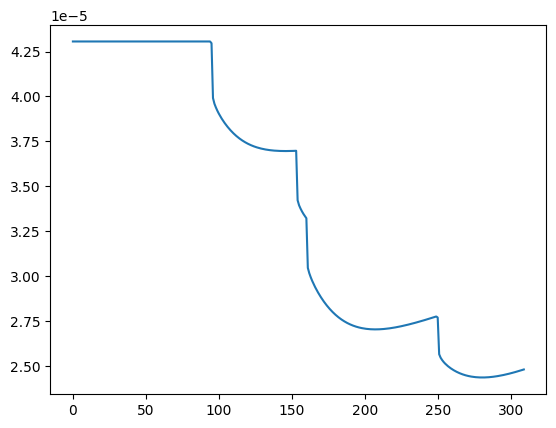

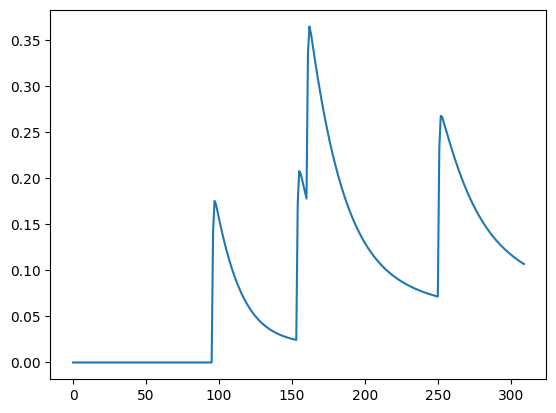

: 

In [ ]:
import numpy as np
import build.pgas_bound as pgas
import matplotlib.pyplot as plt


# Param imports
param_sample_file2 = r"sample_data/output/param_samples_default_janelia_sample_excitatory.dat"
param_samples2 = np.loadtxt(param_sample_file2,skiprows=1,delimiter=",")
good_params2 = param_samples2[:,np.concatenate((np.arange(6),[8]))]
burnin = 100
Cparams_exc = np.mean(good_params2[burnin:,:],axis=0)

Gparam_file="src/spike_find/pgas/20230525_gold.dat"
Gparams = np.loadtxt(Gparam_file)

# Sim
gcamp = pgas.GCaMP(Gparams,Cparams_exc)
#Time/stims
sampling_rate = 200
sim_start = -.05
sim_end = 1.5
sim_time = np.linspace(sim_start,sim_end,num=np.int(np.round((sim_end-sim_start)*sampling_rate)))
#Stims
poisson_rate = 2
event_counts = np.random.poisson(poisson_rate / sampling_rate, len(sim_time))
event_trace = np.where(event_counts > 0, 1, 0)
poisson_stim = sim_time[np.where(event_trace)]
gcamp.integrateOverTime(sim_time.astype(float),poisson_stim.astype(float))
dff = gcamp.getDFFValues()
print("length = "+str(dff.shape))
states = gcamp.getStates()
G_interp = gcamp.getGValues()

print("states.keys() = ",states.keys())
print("G.shape = "+str(states["G"].shape))
print("state.G row 1 = "+str(states["G"][0,:]))
print("G_interp row 1 = "+str(G_interp[0,:]))
print("G row 2 sum = "+str(np.sum(states["G"][0,:])))
plt.figure()
plt.plot(states["G"][:,0])
plt.figure()
plt.plot(dff)#
